In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
import random

# Paths (EDIT THESE 2 ONLY)
source_root = "/content/drive/MyDrive/Dataset/Processed_2D_dataset"
output_root = "/content/drive/MyDrive/Dataset/Processed_2D_dataset_split"

# Create output directories
train_dir = os.path.join(output_root, "Train")
val_dir   = os.path.join(output_root, "Val")
test_dir  = os.path.join(output_root, "Test")

for d in [train_dir, val_dir, test_dir]:
    os.makedirs(d, exist_ok=True)

# Collect all patient folders
patients = [p for p in os.listdir(source_root)
            if os.path.isdir(os.path.join(source_root, p))]

patients.sort()
random.shuffle(patients)

# 60% Train, 20% Val, 20% Test
n = len(patients)
train_n = int(n * 0.6)
val_n   = int(n * 0.2)

train_patients = patients[:train_n]
val_patients   = patients[train_n:train_n + val_n]
test_patients  = patients[train_n + val_n:]

print("Total patients:", n)
print("Train:", len(train_patients))
print("Val:",   len(val_patients))
print("Test:",  len(test_patients))

# Copy folders
def copy_patients(patient_list, destination_root):
    for patient in patient_list:
        src = os.path.join(source_root, patient)
        dst = os.path.join(destination_root, patient)
        shutil.copytree(src, dst)
        print(f"Copied: {patient} → {destination_root}")

# Copy each split set
copy_patients(train_patients, train_dir)
copy_patients(val_patients,   val_dir)
copy_patients(test_patients,  test_dir)

print("\n Dataset successfully split into Train / Val / Test!")


Total patients: 23
Train: 13
Val: 4
Test: 6
Copied: BCBM-RadioGenomics-0-1 → /content/drive/MyDrive/Dataset/Processed_2D_dataset_split/Train
Copied: BCBM-RadioGenomics-8-0 → /content/drive/MyDrive/Dataset/Processed_2D_dataset_split/Train
Copied: BCBM-RadioGenomics-9-0 → /content/drive/MyDrive/Dataset/Processed_2D_dataset_split/Train
Copied: BCBM-RadioGenomics-5-2 → /content/drive/MyDrive/Dataset/Processed_2D_dataset_split/Train
Copied: BCBM-RadioGenomics-5-0 → /content/drive/MyDrive/Dataset/Processed_2D_dataset_split/Train
Copied: BCBM-RadioGenomics-0-0 → /content/drive/MyDrive/Dataset/Processed_2D_dataset_split/Train
Copied: BCBM-RadioGenomics-5-1 → /content/drive/MyDrive/Dataset/Processed_2D_dataset_split/Train
Copied: BCBM-RadioGenomics-13-2 → /content/drive/MyDrive/Dataset/Processed_2D_dataset_split/Train
Copied: BCBM-RadioGenomics-14-1 → /content/drive/MyDrive/Dataset/Processed_2D_dataset_split/Train
Copied: BCBM-RadioGenomics-13-0 → /content/drive/MyDrive/Dataset/Processed_2D_dat

In [ ]:
import os
import numpy as np
from PIL import Image
import shutil

#  Uses  formulas:
#     - Compute histogram h(rk)
#     - pdf = h / (total pixels)
#     - cdf = cumulative sum(pdf)
#     - s_k = round( (cdf[k] - cdf_min) / (1 - cdf_min) * (L-1) )

def textbook_hist_eq(img_array):

    # Histogram (L = 256)
    hist = np.zeros(256, dtype=np.int64)
    for value in img_array.flatten():
        hist[value] += 1

    # Probability density function (PDF)
    total_pixels = img_array.size
    pdf = hist / total_pixels

    # Cumulative distribution function (CDF)
    cdf = np.cumsum(pdf)

    # Normalize
    cdf_min = cdf[np.nonzero(cdf)][0]  # first non‑zero CDF value
    L = 256

    # Mapping function
    mapping = np.round((cdf - cdf_min) / (1 - cdf_min) * (L - 1))
    mapping = np.clip(mapping, 0, 255).astype(np.uint8)

    # Apply mapping to image
    equalized_img = mapping[img_array]

    return equalized_img


# APPLY HISTOGRAM EQUALIZATION TO MRI FOLDERS

def apply_he_to_dataset(input_train_path, output_train_path):

    # Create output Train folder
    os.makedirs(output_train_path, exist_ok=True)

    # Loop through patient folders
    for patient in sorted(os.listdir(input_train_path)):
        p_in = os.path.join(input_train_path, patient)
        if not os.path.isdir(p_in):
            continue

        p_out = os.path.join(output_train_path, patient)
        os.makedirs(p_out, exist_ok=True)

        # MRI and MASK paths
        mri_in = os.path.join(p_in, "MRI")
        mask_in = os.path.join(p_in, "MASK")

        mri_out = os.path.join(p_out, "MRI")
        mask_out = os.path.join(p_out, "MASK")

        os.makedirs(mri_out, exist_ok=True)
        os.makedirs(mask_out, exist_ok=True)

        # PROCESS MRI IMAGES
        if os.path.isdir(mri_in):
            for fname in sorted(os.listdir(mri_in)):
                if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
                    continue

                img_path = os.path.join(mri_in, fname)
                img = Image.open(img_path).convert("L")  # 8-bit grayscale
                img_np = np.array(img)

                # Apply textbook histogram equalization
                he_img_np = textbook_hist_eq(img_np)

                # Save enhanced MRI
                out_path = os.path.join(mri_out, fname)
                Image.fromarray(he_img_np).save(out_path)

        # COPY MASK FOLDER
        if os.path.isdir(mask_in):
            for fname in sorted(os.listdir(mask_in)):
                src = os.path.join(mask_in, fname)
                dst = os.path.join(mask_out, fname)
                shutil.copy2(src, dst)

    print("Histogram Equalization Completed")
    print(f"Output saved to: {output_train_path}")


#  RUN
input_train = "/content/drive/MyDrive/Dataset/Processed_2D_dataset_split/Train"
output_train = "/content/drive/MyDrive/Dataset/Processed_2D_dataset_low/Train_HE"

apply_he_to_dataset(input_train, output_train)


/tmp/ipython-input-1826735884.py:31: RuntimeWarning: invalid value encountered in divide
  mapping = np.round((cdf - cdf_min) / (1 - cdf_min) * (L - 1))
/tmp/ipython-input-1826735884.py:32: RuntimeWarning: invalid value encountered in cast
  mapping = np.clip(mapping, 0, 255).astype(np.uint8)


Histogram Equalization Completed
Output saved to: /content/drive/MyDrive/Dataset/Processed_2D_dataset_low/Train_HE


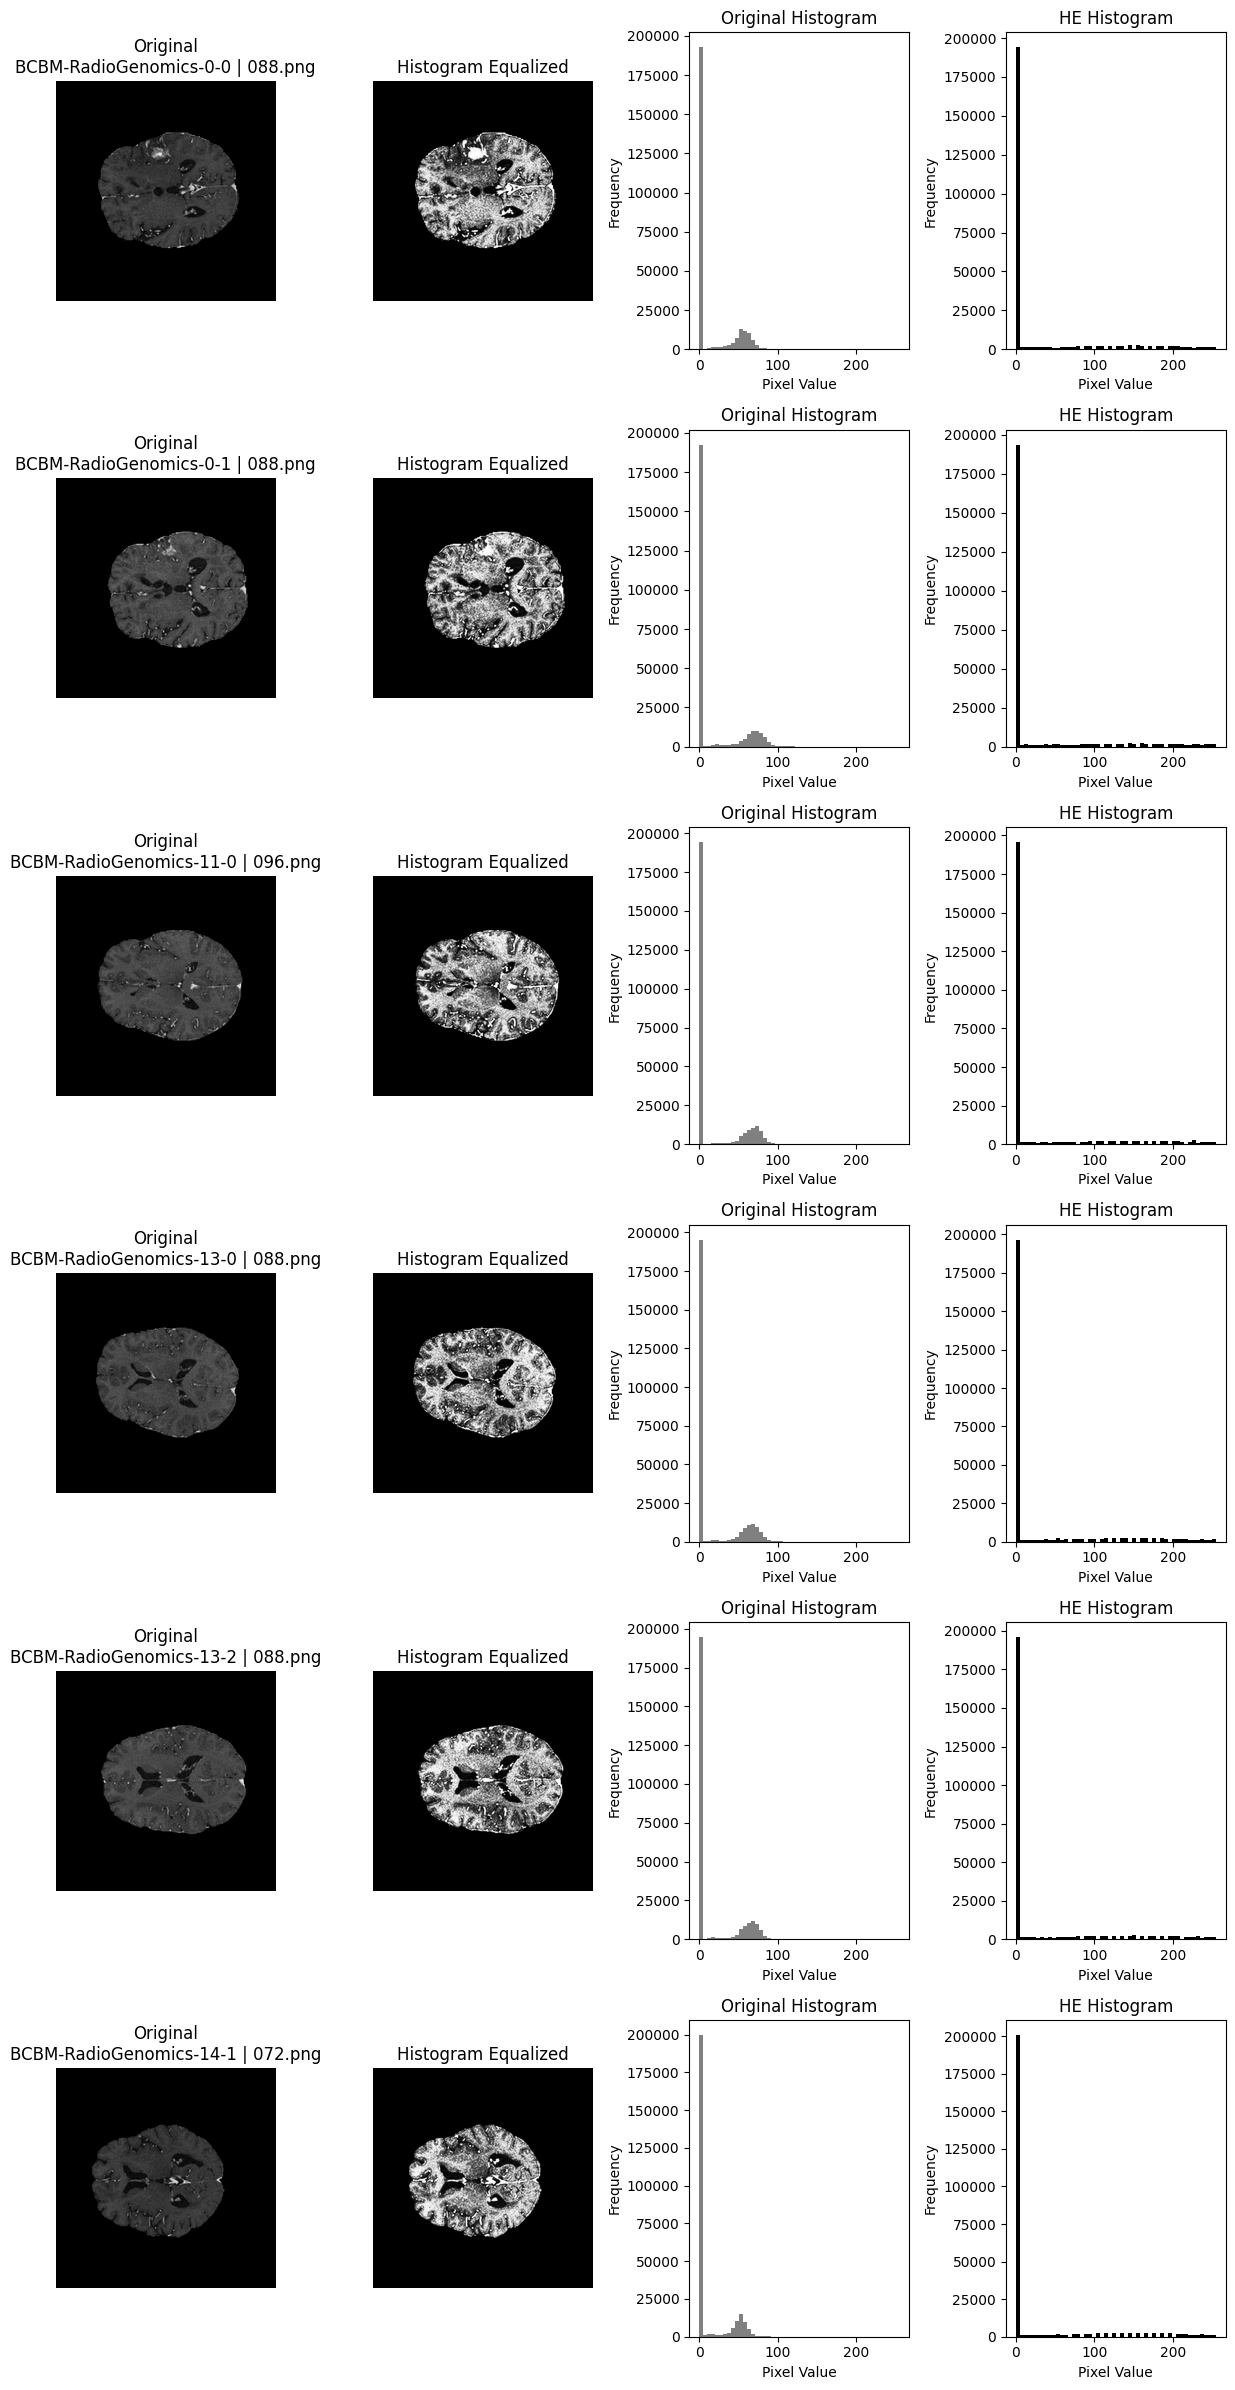

In [ ]:
# Visualization:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

def show_processed_comparison_with_histograms(original_root, processed_root, num_samples=6):

    # Pick patients
    patients = sorted(os.listdir(original_root))
    patients = [p for p in patients if os.path.isdir(os.path.join(original_root, p))]

    plt.figure(figsize=(12, 4 * num_samples))

    count = 0
    for patient in patients:
        if count >= num_samples:
            break

        orig_mri = os.path.join(original_root, patient, "MRI")
        processed_mri = os.path.join(processed_root, patient, "MRI")

        if not os.path.isdir(orig_mri):
            continue

        slices = sorted([f for f in os.listdir(orig_mri) if f.lower().endswith(".png")])
        if len(slices) == 0:
            continue

        # pick a middle slice for reproducibility
        slice_name = slices[len(slices)//2]
        orig_slice_path = os.path.join(orig_mri, slice_name)
        processed_slice_path  = os.path.join(processed_mri, slice_name)

        # load images
        orig_img = np.array(Image.open(orig_slice_path).convert("L"))
        processed_img   = np.array(Image.open(processed_slice_path).convert("L"))

        # PLOT IMAGES
        # Original MRI
        plt.subplot(num_samples, 4, 4 * count + 1)
        plt.imshow(orig_img, cmap='gray')
        plt.title(f"Original\n{patient} | {slice_name}")
        plt.axis("off")

        # Processed MRI
        plt.subplot(num_samples, 4, 4 * count + 2)
        plt.imshow(processed_img, cmap='gray')
        plt.title("Histogram Equalized")
        plt.axis("off")

        # HISTOGRAMS
        # Histogram of original image
        plt.subplot(num_samples, 4, 4 * count + 3)
        plt.hist(orig_img.flatten(), bins=50, color='gray')
        plt.title("Original Histogram")
        plt.xlabel("Pixel Value")
        plt.ylabel("Frequency")

        # Histogram of HE image
        plt.subplot(num_samples, 4, 4 * count + 4)
        plt.hist(processed_img.flatten(), bins=50, color='black')
        plt.title("HE Histogram")
        plt.xlabel("Pixel Value")
        plt.ylabel("Frequency")

        count += 1

    plt.tight_layout()
    plt.show()


# CALL VISUALIZER
original_dataset = "/content/drive/MyDrive/Dataset/Processed_2D_dataset_split/Train"
processed_dataset = "/content/drive/MyDrive/Dataset/Processed_2D_dataset_split/Train_HE"

show_processed_comparison_with_histograms(original_dataset, processed_dataset, num_samples=6)


In [ ]:
import os
import shutil
import numpy as np
from PIL import Image

# CONFIGURATION
INPUT_DIR = "/content/drive/MyDrive/Dataset/Processed_2D_dataset_split/Train"
OUTPUT_DIR = "/content/drive/MyDrive/Dataset/Processed_2D_dataset_split/Train_Gaussian"

KERNEL_SIZE = 5       # 5x5 Gaussian Kernel
SIGMA = 1.0           # Standard deviation for MRI smoothing


# GAUSSIAN KERNEL CREATION
def create_gaussian_kernel(kernel_size, sigma):
    # Create a 2D Gaussian kernel manually using the Gaussian equation.
    # G(x, y) = (1 / (2πσ²)) * exp(-(x² + y²) / (2σ²))

    k = kernel_size // 2
    kernel = np.zeros((kernel_size, kernel_size), dtype=np.float32)

    for x in range(-k, k + 1):
        for y in range(-k, k + 1):
            exponent = -(x**2 + y**2) / (2 * sigma**2)
            kernel[x + k, y + k] = np.exp(exponent)

    kernel /= np.sum(kernel)  # Normalize kernel
    return kernel


# GAUSSIAN FILTER
def apply_gaussian_filter(image, kernel):

    # Apply Gaussian filtering using convolution.
    height, width = image.shape
    k = kernel.shape[0] // 2

    padded_image = np.pad(image, pad_width=k, mode='constant', constant_values=0)
    filtered_image = np.zeros_like(image, dtype=np.float32)

    for i in range(height):
        for j in range(width):
            region = padded_image[i:i + 2*k + 1, j:j + 2*k + 1]
            filtered_image[i, j] = np.sum(region * kernel)

    return np.clip(filtered_image, 0, 255).astype(np.uint8)


# MAIN PROCESSING FUNCTION
def process_train_folder():

    # Applies Gaussian filter to MRI images
    # Copies MASK images unchanged
    kernel = create_gaussian_kernel(KERNEL_SIZE, SIGMA)

    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)

    for patient in os.listdir(INPUT_DIR):
        patient_path = os.path.join(INPUT_DIR, patient)
        if not os.path.isdir(patient_path):
            continue

        print(f"Processing {patient}...")

        # Create output directories
        output_patient_path = os.path.join(OUTPUT_DIR, patient)
        output_mri_path = os.path.join(output_patient_path, "MRI")
        output_mask_path = os.path.join(output_patient_path, "MASK")

        os.makedirs(output_mri_path, exist_ok=True)
        os.makedirs(output_mask_path, exist_ok=True)

        # Process MRI Images
        mri_path = os.path.join(patient_path, "MRI")
        for img_name in os.listdir(mri_path):
            img_path = os.path.join(mri_path, img_name)

            img = Image.open(img_path).convert("L")  # Grayscale
            img_np = np.array(img)

            filtered_img = apply_gaussian_filter(img_np, kernel)

            Image.fromarray(filtered_img).save(
                os.path.join(output_mri_path, img_name)
            )

        # Copy MASK Folder
        mask_path = os.path.join(patient_path, "MASK")
        for mask_name in os.listdir(mask_path):
            shutil.copy(
                os.path.join(mask_path, mask_name),
                os.path.join(output_mask_path, mask_name)
            )

    print("Gaussian filtering completed successfully!")


# RUN
if __name__ == "__main__":
    process_train_folder()


Processing BCBM-RadioGenomics-9-0...
Processing BCBM-RadioGenomics-7-0...
Processing BCBM-RadioGenomics-5-1...
Processing BCBM-RadioGenomics-5-0...
Processing BCBM-RadioGenomics-5-2...
Processing BCBM-RadioGenomics-3-0...
Processing BCBM-RadioGenomics-14-1...
Processing BCBM-RadioGenomics-13-2...
Processing BCBM-RadioGenomics-13-0...
Processing BCBM-RadioGenomics-11-0...
Processing BCBM-RadioGenomics-0-0...
Processing BCBM-RadioGenomics-0-1...
Processing BCBM-RadioGenomics-8-0...
Gaussian filtering completed successfully!


In [ ]:
import os

folder_path = "/content/drive/MyDrive/Dataset/Processed_2D_dataset_split/Train_HE/BCBM-RadioGenomics-9-0/MRI"

num_files = len([
    f for f in os.listdir(folder_path)
    if os.path.isfile(os.path.join(folder_path, f))
])

print("Number of files:", num_files)


Number of files: 192


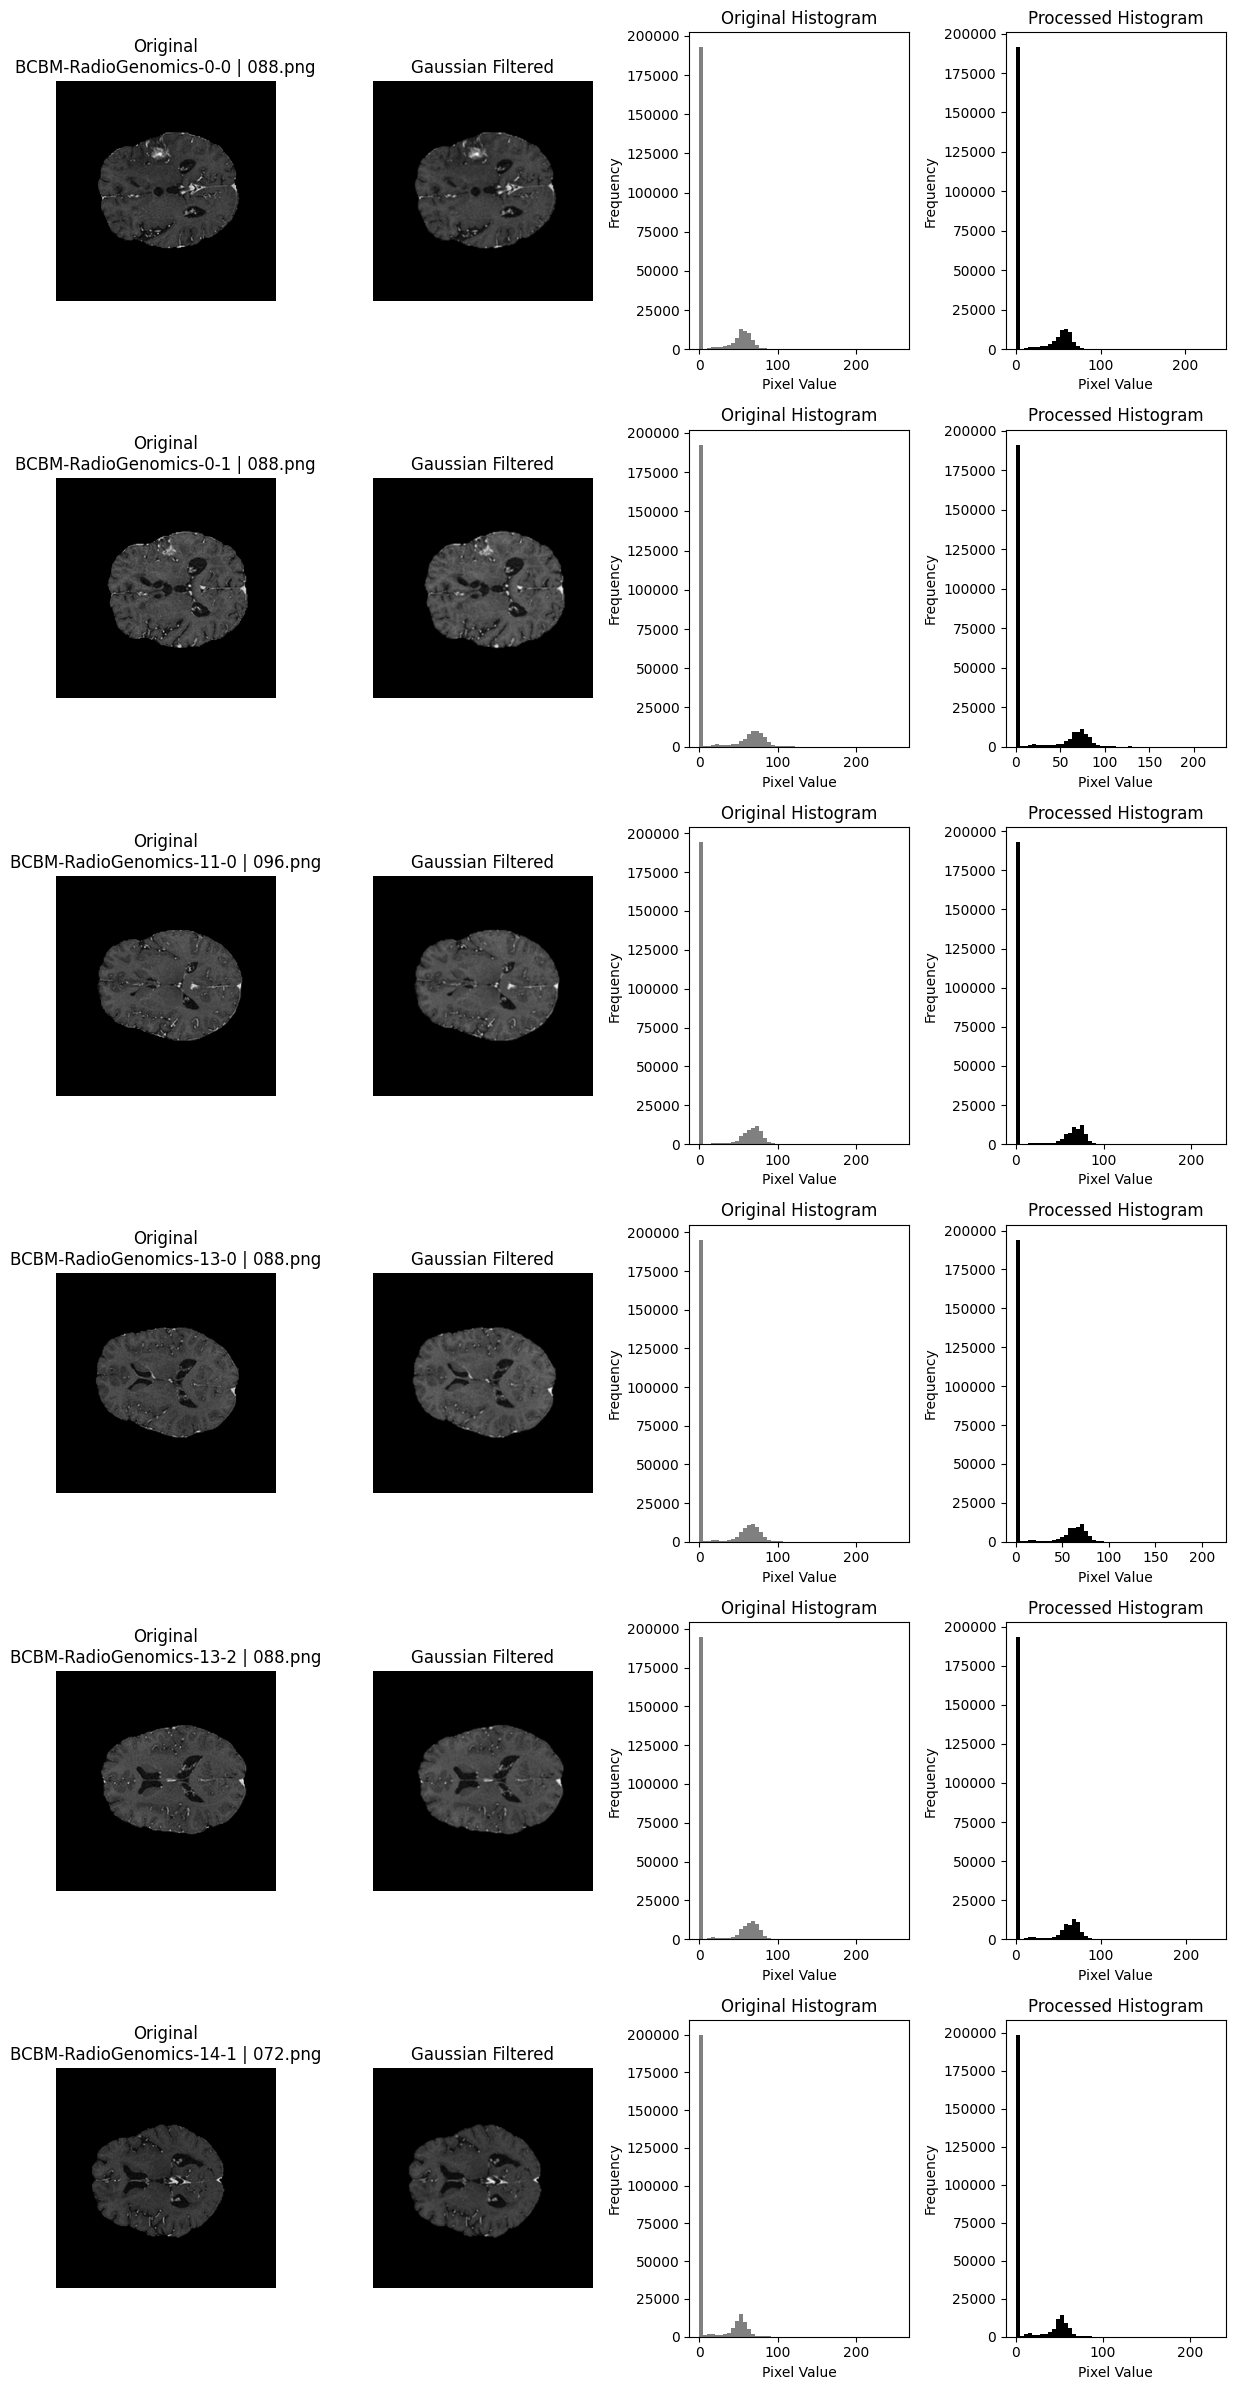

In [ ]:
# Visualization:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

def show_processed_comparison_with_histograms(original_root, processed_root, num_samples=6):

    # Pick patients
    patients = sorted(os.listdir(original_root))
    patients = [p for p in patients if os.path.isdir(os.path.join(original_root, p))]

    plt.figure(figsize=(12, 4 * num_samples))

    count = 0
    for patient in patients:
        if count >= num_samples:
            break

        orig_mri = os.path.join(original_root, patient, "MRI")
        processed_mri = os.path.join(processed_root, patient, "MRI")

        if not os.path.isdir(orig_mri):
            continue

        slices = sorted([f for f in os.listdir(orig_mri) if f.lower().endswith(".png")])
        if len(slices) == 0:
            continue

        # pick a middle slice for reproducibility
        slice_name = slices[len(slices)//2]
        orig_slice_path = os.path.join(orig_mri, slice_name)
        processed_slice_path  = os.path.join(processed_mri, slice_name)

        # load images
        orig_img = np.array(Image.open(orig_slice_path).convert("L"))
        processed_img   = np.array(Image.open(processed_slice_path).convert("L"))

        # PLOT IMAGES
        # Original MRI
        plt.subplot(num_samples, 4, 4 * count + 1)
        plt.imshow(orig_img, cmap='gray')
        plt.title(f"Original\n{patient} | {slice_name}")
        plt.axis("off")

        # Processed MRI
        plt.subplot(num_samples, 4, 4 * count + 2)
        plt.imshow(processed_img, cmap='gray')
        plt.title("Gaussian Filtered")
        plt.axis("off")

        # HISTOGRAMS
        # Histogram of original image
        plt.subplot(num_samples, 4, 4 * count + 3)
        plt.hist(orig_img.flatten(), bins=50, color='gray')
        plt.title("Original Histogram")
        plt.xlabel("Pixel Value")
        plt.ylabel("Frequency")

        # Histogram of HE image
        plt.subplot(num_samples, 4, 4 * count + 4)
        plt.hist(processed_img.flatten(), bins=50, color='black')
        plt.title("Processed Histogram")
        plt.xlabel("Pixel Value")
        plt.ylabel("Frequency")

        count += 1

    plt.tight_layout()
    plt.show()


# CALL VISUALIZER
original_dataset = "/content/drive/MyDrive/Dataset/Processed_2D_dataset_split/Train"
processed_dataset = "/content/drive/MyDrive/Dataset/Processed_2D_dataset_split/Train_Gaussian"

show_processed_comparison_with_histograms(original_dataset, processed_dataset, num_samples=6)


In [ ]:
import os
import shutil
import numpy as np
from PIL import Image

# CONFIGURATION
INPUT_DIR = "/content/drive/MyDrive/Dataset/Processed_2D_dataset_split/Train"
OUTPUT_DIR = "/content/drive/MyDrive/Dataset/Processed_2D_dataset_split/Train_Laplacian"


# 8-NEIGHBORHOOD LAPLACIAN KERNEL
def create_laplacian_kernel():

    # Creates a 3x3 8-neighborhood Laplacian kernel.
    kernel = np.array([
        [ -1,  -1,  -1],
        [ -1,   8,  -1],
        [ -1,  -1,  -1]
    ], dtype=np.int32)
    return kernel


#  LAPLACIAN FILTER
def apply_laplacian_filter(image, kernel):

    # Apply 8-neighborhood Laplacian filter using convolution.
    height, width = image.shape
    k = kernel.shape[0] // 2

    padded_image = np.pad(image, pad_width=k, mode='constant', constant_values=0)
    laplacian_image = np.zeros_like(image, dtype=np.int32)

    for i in range(height):
        for j in range(width):
            region = padded_image[i:i+2*k+1, j:j+2*k+1]
            laplacian_image[i, j] = np.sum(region * kernel)

    return laplacian_image


# IMAGE SHARPENING
def sharpen_image(original, laplacian):

    # Adds Laplacian response to original image to enhance edges.

    sharpened = original + laplacian
    return np.clip(sharpened, 0, 255).astype(np.uint8)


# MAIN PROCESSING FUNCTION
def process_train_folder():

    # Applies 8-neighborhood Laplacian filtering to MRI images
    # and copies MASK images unchanged.

    kernel = create_laplacian_kernel()

    if not os.path.exists(OUTPUT_DIR):
        os.makedirs(OUTPUT_DIR)

    for patient in os.listdir(INPUT_DIR):
        patient_path = os.path.join(INPUT_DIR, patient)
        if not os.path.isdir(patient_path):
            continue

        print(f"Processing {patient}...")

        # Create output directories
        output_patient_path = os.path.join(OUTPUT_DIR, patient)
        output_mri_path = os.path.join(output_patient_path, "MRI")
        output_mask_path = os.path.join(output_patient_path, "MASK")

        os.makedirs(output_mri_path, exist_ok=True)
        os.makedirs(output_mask_path, exist_ok=True)

        # Process MRI Images
        mri_path = os.path.join(patient_path, "MRI")
        for img_name in os.listdir(mri_path):
            img_path = os.path.join(mri_path, img_name)

            img = Image.open(img_path).convert("L")  # Grayscale
            img_np = np.array(img)

            laplacian = apply_laplacian_filter(img_np, kernel)
            sharpened_img = sharpen_image(img_np, laplacian)

            Image.fromarray(sharpened_img).save(
                os.path.join(output_mri_path, img_name)
            )

        # Copy MASK Images
        mask_path = os.path.join(patient_path, "MASK")
        for mask_name in os.listdir(mask_path):
            shutil.copy(
                os.path.join(mask_path, mask_name),
                os.path.join(output_mask_path, mask_name)
            )

    print(" 8-neighborhood Laplacian filtering completed successfully!")


# RUN
if __name__ == "__main__":
    process_train_folder()


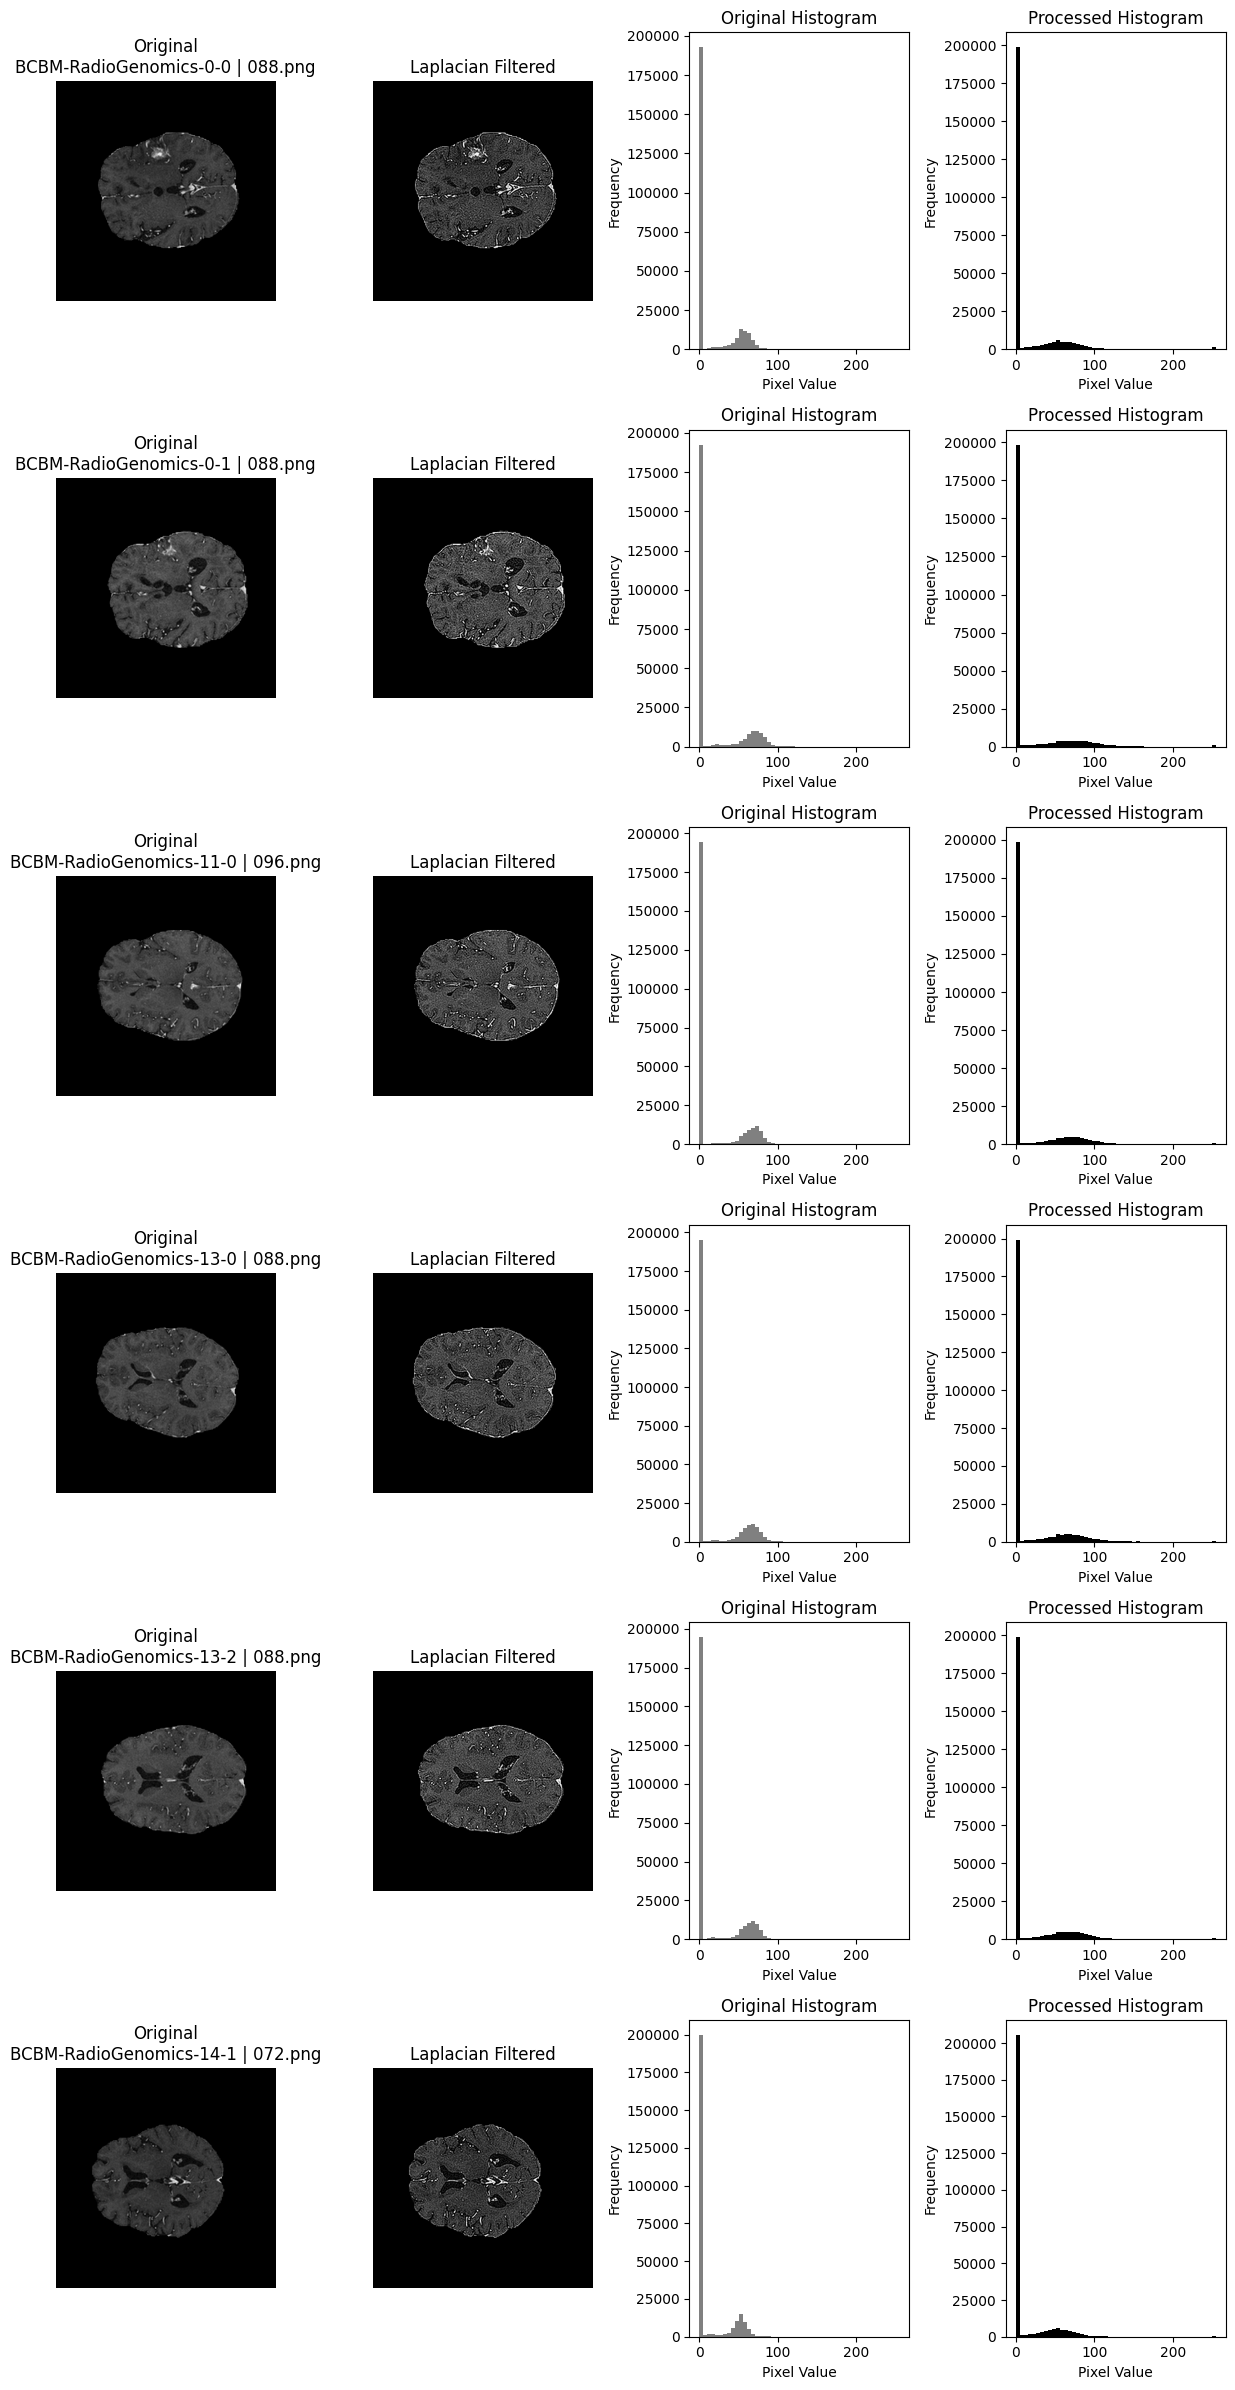

In [ ]:
# Visualization:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

def show_processed_comparison_with_histograms(original_root, processed_root, num_samples=6):

    # Pick patients
    patients = sorted(os.listdir(original_root))
    patients = [p for p in patients if os.path.isdir(os.path.join(original_root, p))]

    plt.figure(figsize=(12, 4 * num_samples))

    count = 0
    for patient in patients:
        if count >= num_samples:
            break

        orig_mri = os.path.join(original_root, patient, "MRI")
        processed_mri = os.path.join(processed_root, patient, "MRI")

        if not os.path.isdir(orig_mri):
            continue

        slices = sorted([f for f in os.listdir(orig_mri) if f.lower().endswith(".png")])
        if len(slices) == 0:
            continue

        # pick a middle slice for reproducibility
        slice_name = slices[len(slices)//2]
        orig_slice_path = os.path.join(orig_mri, slice_name)
        processed_slice_path  = os.path.join(processed_mri, slice_name)

        # load images
        orig_img = np.array(Image.open(orig_slice_path).convert("L"))
        processed_img   = np.array(Image.open(processed_slice_path).convert("L"))

        # PLOT IMAGES
        # Original MRI
        plt.subplot(num_samples, 4, 4 * count + 1)
        plt.imshow(orig_img, cmap='gray')
        plt.title(f"Original\n{patient} | {slice_name}")
        plt.axis("off")

        # Processed MRI
        plt.subplot(num_samples, 4, 4 * count + 2)
        plt.imshow(processed_img, cmap='gray')
        plt.title("Laplacian Filtered")
        plt.axis("off")

        # HISTOGRAMS
        # Histogram of original image
        plt.subplot(num_samples, 4, 4 * count + 3)
        plt.hist(orig_img.flatten(), bins=50, color='gray')
        plt.title("Original Histogram")
        plt.xlabel("Pixel Value")
        plt.ylabel("Frequency")

        # Histogram of HE image
        plt.subplot(num_samples, 4, 4 * count + 4)
        plt.hist(processed_img.flatten(), bins=50, color='black')
        plt.title("Processed Histogram")
        plt.xlabel("Pixel Value")
        plt.ylabel("Frequency")

        count += 1

    plt.tight_layout()
    plt.show()


# CALL VISUALIZER
original_dataset = "/content/drive/MyDrive/Dataset/Processed_2D_dataset_split/Train"
processed_dataset = "/content/drive/MyDrive/Dataset/Processed_2D_dataset_split/Train_Laplacian"

show_processed_comparison_with_histograms(original_dataset, processed_dataset, num_samples=6)
